In [ ]:
import numpy as np
import glob
from netCDF4 import Dataset, date2num
import os
from datetime import datetime
from datetime import timedelta
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cft

Plot the spatial distribution of vegetation fraction for the four experiments - Figure S2

In [ ]:
#extract vegetation fraction

# Constants
Rd = 287.05  # J/kg/K

# file paths
paths = {
    "Default(Bulk+NoUCM)": "/g/data/fy29/mf9078/run_WRF/etamodified/output/0out/animation/",
    "LCZ": "/g/data/fy29/mf9078/run_WRF/etamodified/output/1out/animation/",
    "WSF-MB": "/g/data/fy29/mf9078/run_WRF/etamodified/output/3out/animation/",
    "Geoscape": "/g/data/fy29/mf9078/run_WRF/etamodified/output/4out/animation/"
}

#Loop through all the scenarios
for i, (label, sc_path) in enumerate(paths.items()):
    file_list = sorted(glob.glob(os.path.join(sc_path, "wrfout_d02_2017-01-*")))
    
    n = 0 #counting the number of time steps matching the if condition in the loop
    # Loop through files
    for i, fpath in enumerate(file_list):
        #print(f"Processing {fpath}")
        ds = xr.open_dataset(fpath)
        
        # Parse timestamp and convert to AEST
        timestamp_utc = datetime.strptime(os.path.basename(fpath)[11:], "%Y-%m-%d_%H:%M:%S")
        timestamp_aest = timestamp_utc + timedelta(hours=10)

        T2 = ds["T2"] 
        ve = ds["FVEG"]
        
        #patterns during the day
        bsr = list(range(3,7)) #3 to 6 am: before sunrise
        bsr_1st = (timestamp_aest.day == 10 and timestamp_aest.hour == 3) #1st entry in the list
        
        morning = list(range(7,11)) #7 to 10 am: more relatable to everyday life
        morning_1st = (timestamp_aest.day == 10 and timestamp_aest.hour == 7) #1st entry in the list
        
        #morning = list(range(6,11)) #6 to 10 am: the underlying pattern
        #morning_1st = (timestamp_aest.day == 10 and timestamp_aest.hour == 6) #1st entry in the list

        peak = list(range(11,15)) #11 am to 14; peak solar heating
        peak_1st = (timestamp_aest.day == 10 and timestamp_aest.hour == 11) #1st entry in the list

        aft = list(range(15,19)) #15 to 18; late afternoon
        aft_1st = (timestamp_aest.day == 10 and timestamp_aest.hour == 15) #1st entry in the list

        eve = list(range(19,23))   #evening/3 hours after sunset: 19-22
        eve_1st = (timestamp_aest.day == 10 and timestamp_aest.hour == 19) #1st entry in the list


        if timestamp_aest.hour in bsr:
            if bsr_1st:  #first entry matching the conditions (on first day, 10th of January)
                T_sum = T2
                ve_sum = ve
                n += 1
            else:
                T_sum += T2
                ve_sum += ve
                n += 1

    T_avg = T_sum/n
    ve_avg = ve_sum/n

    if label == "Default(Bulk+NoUCM)":
        T_avg_bulk = T_avg
        ve_avg_bulk = ve_avg
    elif label == "LCZ":
        T_avg_LCZ = T_avg
        ve_avg_LCZ = ve_avg
    elif label == "WSF-MB":
        T_avg_WSF3DMSB = T_avg
        ve_avg_WSF3DMSB = ve_avg
    else:
        T_avg_Geoscape = T_avg
        ve_avg_Geoscape = ve_avg
    

ERROR 1: PROJ: proj_create_from_database: Open of /g/data/xp65/public/./apps/med_conda/envs/analysis3-25.09/share/proj failed


In [ ]:
#vegetation fraction with regard to urban fraction (so that vegetation fraction + urban fraction + bare soil fraction = 1)
files = {   
    "LCZ": "/g/data/fy29/mf9078/run_WRF/etamodified/setup/1rad/wrfinput_d02",
    "WSF-MB": "/g/data/fy29/mf9078/run_WRF/etamodified/setup/3rad/wrfinput_d02",
    "Geoscape": "/g/data/fy29/mf9078/run_WRF/etamodified/setup/4rad/wrfinput_d02"
}

ds_l = xr.open_dataset(files["LCZ"])
ds_w = xr.open_dataset(files["WSF-MB"])
ds_g = xr.open_dataset(files["Geoscape"])

uf_l = ds_l["FRC_URB2D"]
uf_w = ds_w["FRC_URB2D"]
uf_g = ds_g["FRC_URB2D"]

ve_l = (1 - uf_l)*ve_avg_LCZ
ve_w = (1 - uf_w)*ve_avg_WSF3DMSB
ve_g = (1 - uf_g)*ve_avg_Geoscape

In [ ]:
#mask

# Constants
lat_min, lat_max = -34.14, -33.55
lon_min, lon_max = 150.57, 151.37

file_luindex = "/g/data/fy29/mf9078/run_WRF/etamodified/output/4out/animation/wrfout_d02_2017-01-12_21:00:00" #any wrfout with 10-category LCZ, i.e., any scenario but bulk

# Initialize on first file to get the subset bounds and mask
ds = xr.open_dataset(file_luindex) 
XLAT = ds["XLAT"]
XLONG = ds["XLONG"]
LU_INDEX = ds["LU_INDEX"]

lat_mask = (XLAT >= lat_min) & (XLAT <= lat_max)
lon_mask = (XLONG >= lon_min) & (XLONG <= lon_max)
lu_mask = (LU_INDEX >= 51) & (LU_INDEX <= 60)
region_mask = lat_mask & lon_mask & lu_mask

T_avg_bulk_masked = T_avg_bulk.where(region_mask) -273.15
T_avg_LCZ_masked = T_avg_LCZ.where(region_mask) -273.15
T_avg_WSF3DMSB_masked = T_avg_WSF3DMSB.where(region_mask) -273.15
T_avg_Geoscape_masked = T_avg_Geoscape.where(region_mask) -273.15

ve_avg_bulk_masked = ve_avg_bulk.where(region_mask) 
ve_avg_LCZ_masked = ve_avg_LCZ.where(region_mask) 
ve_avg_WSF3DMSB_masked = ve_avg_WSF3DMSB.where(region_mask) 
ve_avg_Geoscape_masked = ve_avg_Geoscape.where(region_mask) 

ve_l_masked = ve_l.where(region_mask)
ve_w_masked = ve_w.where(region_mask) 
ve_g_masked = ve_g.where(region_mask)

/scratch/pu02/mf9078/tmp/ipykernel_2689026/855771506.py:16: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


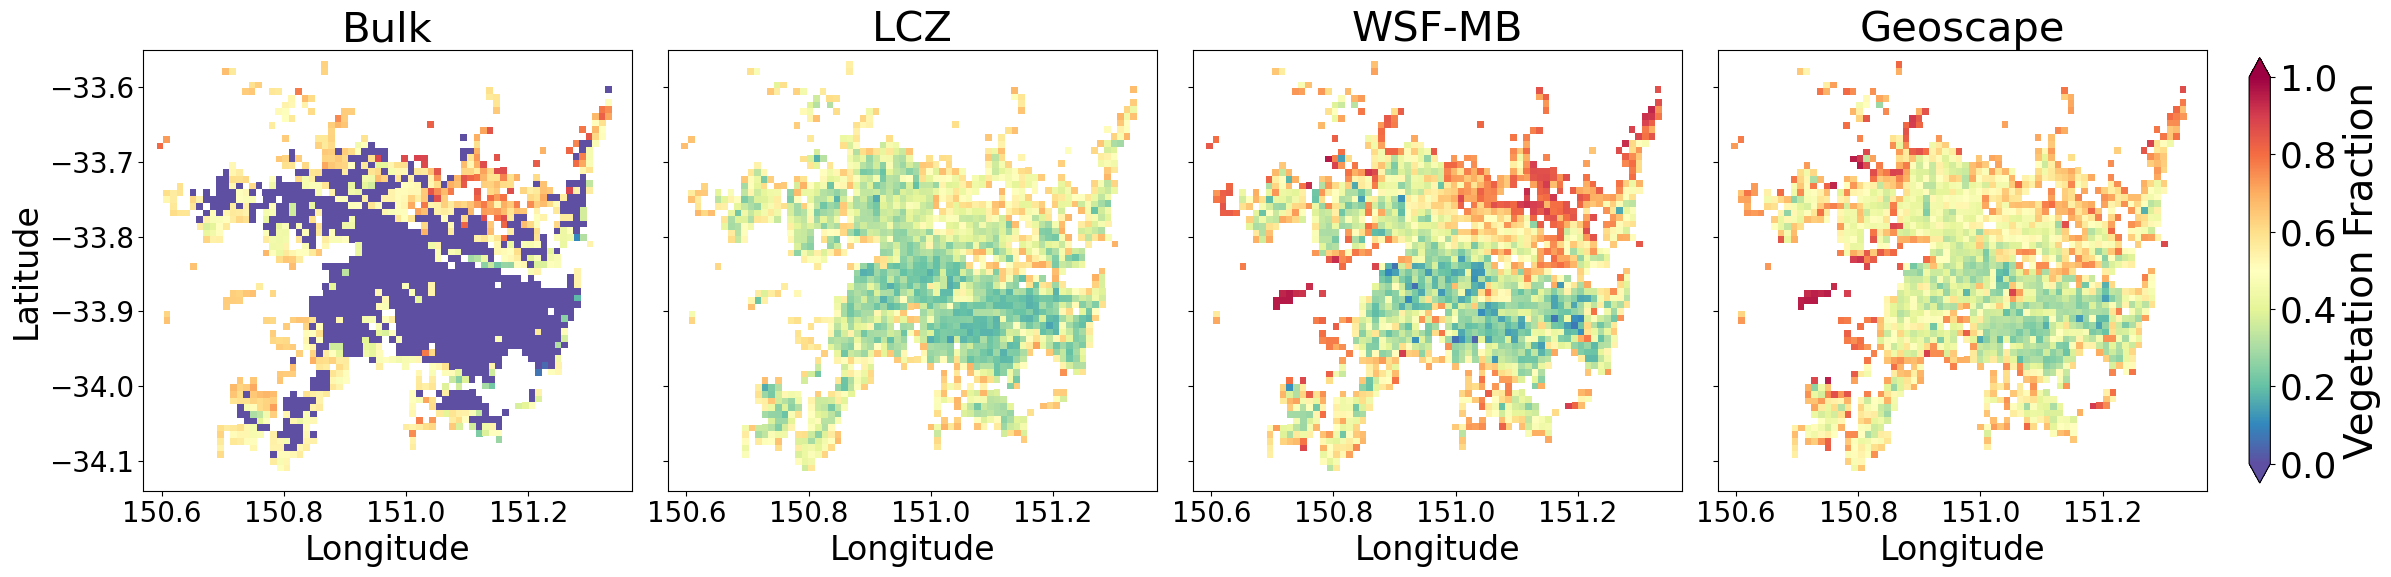

In [ ]:
#plot
sc_dict = {
    "Bulk": ve_avg_bulk_masked,
    "LCZ": ve_l_masked,
    "WSF-MB": ve_w_masked,
    "Geoscape": ve_g_masked
}

lat_min, lat_max = -34.14, -33.55
lon_min, lon_max = 150.57, 151.37

# Set up figure
fig, axs = plt.subplots(1, 4, figsize=(22, 5), sharey=True, constrained_layout=True)
plt.tight_layout() 
# Color range

vmin_morning, vmax_morning = 25, 28
vmin_peak, vmax_peak= 25, 35
vmin_aft, vmax_aft= 24, 32
vmin_bsr, vmax_bsr= 0, 1#21, 27#22.5, 28.5  #23, 26

# Loop through files
for i, (label, scname) in enumerate(sc_dict.items()):

    # Plot on subplot
    im = scname.plot(
        ax=axs[i],
        x='XLONG',
        y='XLAT',
        cmap='Spectral_r', #'RdYlBu_r',#'rainbow', #
        vmin=vmin_bsr,
        vmax=vmax_bsr,
        add_colorbar=False
    )

    axs[i].set_ylim(lat_min, lat_max)
    axs[i].set_xlim(lon_min, lon_max)
    axs[i].set_title(label, fontsize=30)
    axs[i].set_xlabel("Longitude", fontsize=24)
    if i == 0:
        axs[i].set_ylabel("Latitude", fontsize=24)
    else:
        axs[i].set_ylabel("")
        axs[i].tick_params(labelleft=False)

    axs[i].tick_params(axis='both', which='major', labelsize=20)

# Shared colorbar
cbar = fig.colorbar(im, ax=axs, orientation='vertical', fraction=0.01, pad=0.02, extend='both') #shrink=0.8, 
cbar.set_label("Vegetation Fraction", fontsize=28)
cbar.ax.tick_params(labelsize=26) 

plt.savefig("ve-4x4-bsr.png", bbox_inches='tight', dpi=300)
plt.show()